# One cause or two?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/acerbilab/one-cause-or-two/blob/main/notebook/one_cause_or_two.ipynb)

A flash and a beep arrive at the same moment. Did they come from the same thing? In *Bayesian causal inference* (Körding et al., 2007), an observer answers by comparing two explanations of its noisy measurements: one common source, or two independent ones. How well such a model describes people depends on its ingredients: how noisy each sense is at each location, and what the observer expects before any signal arrives. Models in the field often assume the same noise everywhere, and a simple prior such as a Gaussian. Liu, Holland, Ma & Acerbi (2026) inferred these ingredients from behaviour. People's data were best described by sensory noise that is lowest straight ahead and levels off towards the periphery, and by a prior with a narrow central peak and smoother tails.

This notebook works through the paper's question in miniature, on simulated data. It builds the observer, simulates one participant whose sensory noise depends on eccentricity, fits a constant-noise model and an eccentricity-dependent one with [PyBADS](https://acerbilab.github.io/pybads/), and compares them with [PyVBMC](https://acerbilab.github.io/pyvbmc/).

- **Paper:** Liu S, Holland T, Ma WJ & Acerbi L (2026). Distilling noise characteristics and prior expectations in multisensory causal inference. *PLOS Computational Biology* 22(5): e1014251. [doi:10.1371/journal.pcbi.1014251](https://doi.org/10.1371/journal.pcbi.1014251)
- **Film:** [*One cause or two?*](https://acerbilab.github.io/one-cause-or-two/), a short animation about the study.

Running the notebook takes several minutes on a CPU, most of it in PyVBMC. Random seeds are fixed.

In [1]:
%pip install -q pybads pyvbmc

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from pybads import BADS
from pyvbmc import VBMC
from pyvbmc.priors import SplineTrapezoidal

# The film's colours, darkened to read on white
SIGHT, SOUND, MODEL, PRIOR = "#1B8BD0", "#0F7F4F", "#D08000", "#8B5CF6"
CONST, INK, MUTED = "#5F6673", "#1F2328", "#8C959F"

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.grid": True,
    "grid.color": "#E8EAED",
    "grid.linewidth": 0.6,
    "xtick.color": "#57606A",
    "ytick.color": "#57606A",
    "text.color": INK,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
})

## 1 · The observer

The observer follows the paper's Methods. A stimulus at location $s$ (in degrees; 0 is straight ahead) produces a noisy measurement

$$x \mid s \sim \mathcal{N}\big(s,\ \sigma^2(s)\big),$$

with a separate noise function for vision, $\sigma_V(s)$, and for hearing, $\sigma_A(s)$, from one of two families:

| Model | $\sigma(s)$ | Shape |
|---|---|---|
| **Const** | $\sigma_0$ | the same noise everywhere |
| **Exp** | $\sigma_0 + k_1\,(1 - e^{-k_2\lvert s\rvert})$ | lowest straight ahead, levelling off at $\sigma_0 + k_1$ |

The observer's prior over location is centred straight ahead, $p(s) = \mathcal{N}(0, \sigma_s^2)$, and its likelihood uses the true noise function. Three of the paper's five tasks are modelled:

- **UV, UA**: localize a flash or a beep. The observer reports its posterior mean $\hat s(x) = \int s\,p(s \mid x)\,ds$, plus Gaussian motor noise with SD $\sigma_\text{motor}$. With probability $\lambda$ the trial is a lapse, and the response is uniform on $[-45°, 45°]$.
- **BC**: were the flash and the beep in the same place? The observer computes the posterior probability of a common cause (paper eqs. 1–2), with prior probability $p_\text{same}$:
$$p(C{=}1 \mid x_V, x_A) = \frac{p_\text{same}\,\ell_1}{p_\text{same}\,\ell_1 + (1 - p_\text{same})\,\ell_2},\qquad
\ell_1 = \int p(x_V \mid s)\,p(x_A \mid s)\,p(s)\,ds,\qquad
\ell_2 = \int p(x_V \mid s)\,p(s)\,ds \int p(x_A \mid s)\,p(s)\,ds.$$
It answers "same" with exactly this probability (*probability matching*, eq. 14), the strategy that generally fitted best in the paper, with model averaging a close second. On a lapse it guesses (eq. 15). Probability matching also keeps the likelihood smooth in the parameters, which helps the optimizers; on a grid, a hard threshold would make it jagged.

The experimenter sees the stimulus but not the measurement, so the probability of a response integrates over the measurement: $p(r \mid s) = \int p(r \mid x)\,\mathcal{N}\big(x;\,s,\,\sigma^2(s)\big)\,dx$, and a double integral for BC.

**Grids.** With eccentricity-dependent noise, the likelihood $\mathcal N\big(x; s, \sigma^2(s)\big)$ is not a Gaussian function of $s$: both its width and its normalisation $1/\sigma(s)$ change with $s$. The posterior has no closed form, so, as in the paper, every integral is computed on a grid with the trapezoidal rule.

**Speed.** What the observer does depends only on its measurements, not on the trial they came from. So, for each parameter vector, the code tabulates the estimate $\hat s(x)$ on a grid of $x$, and $p(C{=}1 \mid x_V, x_A)$ on a grid of pairs, with a few matrix products. Each trial's response probability is then a sum over the $x$ grid weighted by $\mathcal N\big(x; s, \sigma^2(s)\big)$; for BC it is a bilinear form in the two weight vectors. A full log-likelihood takes a few milliseconds.

**Simplifications.** Compared with the paper, the miniature has:
- one visual reliability level (the paper had three, with the noise scaled by $\alpha_\text{med}$ and $\alpha_\text{low}$);
- no bisensory localization tasks (BV, BA), no extra noise on bisensory trials ($\beta_V$, $\beta_A$), and no auditory range recalibration ($\rho_A$);
- a Gaussian prior (the paper's best-fitting prior was a Gaussian–Laplace mixture);
- one $k_2$ shared by vision and hearing, and motor noise fixed at $\sigma_\text{motor} = 0.5°$, small next to the sensory noise.

That leaves 8 free parameters for Exp and 5 for Const.

In [3]:
# Grids in degrees (0 = straight ahead)
S = np.arange(-60, 60.001, 0.25)  # latent location s (the observer's hypotheses)
X = np.arange(-50, 50.001, 0.5)   # measurement x


def trapezoid_weights(grid):
    w = np.full(grid.size, grid[1] - grid[0])
    w[[0, -1]] /= 2
    return w


DS, DX = trapezoid_weights(S), trapezoid_weights(X)
SIGMA_MOTOR = 0.5       # motor noise SD (deg), fixed
RESPONSE_RANGE = 90.0   # lapses are uniform on [-45, 45] deg


def normpdf(x, mu, sd):
    z = (x - mu) / sd
    return np.exp(-0.5 * z * z) / (np.sqrt(2 * np.pi) * sd)


def noise_sd(s, sigma0, k1=0.0, k2=0.0):
    # Exp family; k1 = 0 gives Const noise
    return sigma0 + k1 * (1 - np.exp(-k2 * np.abs(s)))


PARAMS = {
    "Const": ["sigma_V", "sigma_A", "sigma_s", "p_same", "lapse"],
    "Exp": ["sigma0_V", "k1_V", "sigma0_A", "k1_A", "k2", "sigma_s", "p_same", "lapse"],
}


def unpack(theta, model):
    # -> noise_V, noise_A, sigma_s, p_same, lapse, where noise = (sigma0, k1, k2) arguments of noise_sd
    p = dict(zip(PARAMS[model], theta))
    if model == "Const":
        noise_V, noise_A = (p["sigma_V"],), (p["sigma_A"],)
    else:
        noise_V = (p["sigma0_V"], p["k1_V"], p["k2"])
        noise_A = (p["sigma0_A"], p["k1_A"], p["k2"])
    return noise_V, noise_A, p["sigma_s"], p["p_same"], p["lapse"]


def observer_maps(noise_V, noise_A, sigma_s, p_same):
    # What the observer computes from its measurements, tabulated on the x grid
    prior = normpdf(S, 0, sigma_s) * DS                   # p(s) ds
    L_V = normpdf(X[:, None], S, noise_sd(S, *noise_V))   # p(x | s) as a matrix [x, s], 1/sigma(s) included
    L_A = normpdf(X[:, None], S, noise_sd(S, *noise_A))
    evid_V, evid_A = L_V @ prior, L_A @ prior             # p(x) = ∫ p(x | s) p(s) ds
    s_hat_V = L_V @ (prior * S) / np.maximum(evid_V, 1e-300)  # posterior means
    s_hat_A = L_A @ (prior * S) / np.maximum(evid_A, 1e-300)
    like_same = (L_V * prior) @ L_A.T                     # eq. (1) on the (x_V, x_A) grid
    like_diff = np.outer(evid_V, evid_A)                  # eq. (2)
    num = p_same * like_same
    p_C1 = num / np.maximum(num + (1 - p_same) * like_diff, 1e-300)  # floors act only far outside the stimuli
    return s_hat_V, s_hat_A, p_C1


def measurement_weights(s, noise):
    # One row per stimulus: N(x; s, sigma(s)^2) dx on the x grid, normalised to sum to 1
    w = normpdf(X, s[:, None], noise_sd(s, *noise)[:, None]) * DX
    return w / w.sum(axis=1, keepdims=True)


def log_likelihood(theta, model, data):
    noise_V, noise_A, sigma_s, p_same, lapse = unpack(theta, model)
    s_hat_V, s_hat_A, p_C1 = observer_maps(noise_V, noise_A, sigma_s, p_same)
    ll = 0.0
    # Localization: p(r | s) = (1 - lapse) ∫ N(r; s_hat(x), sigma_motor^2) N(x; s, sigma(s)^2) dx + lapse / 90
    for task, s_hat, noise in (("UV", s_hat_V, noise_V), ("UA", s_hat_A, noise_A)):
        s, r = data[task]["s"], data[task]["r"]
        p = np.sum(measurement_weights(s, noise) * normpdf(r[:, None], s_hat, SIGMA_MOTOR), axis=1)
        ll += np.sum(np.log((1 - lapse) * p + lapse / RESPONSE_RANGE))
    # Same/different: p("same" | s_V, s_A) = lapse / 2 + (1 - lapse) ∬ p(C=1 | x_V, x_A) p(x_V | s_V) p(x_A | s_A)
    bc = data["BC"]
    W_V = measurement_weights(bc["s_V"], noise_V)
    W_A = measurement_weights(bc["s_A"], noise_A)
    p_same_resp = lapse / 2 + (1 - lapse) * np.sum((W_V @ p_C1) * W_A, axis=1)
    ll += np.sum(np.log(np.where(bc["same"], p_same_resp, 1 - p_same_resp)))
    return ll

## 2 · A check against the closed form

With constant noise and a Gaussian prior, all the integrals above have closed forms (Körding et al., 2007). The film draws its diagrams with that closed-form observer ([`causalInference` in `film/src/lib/math.ts`](https://github.com/acerbilab/one-cause-or-two/blob/main/film/src/lib/math.ts)). Here is a port, compared with the grid observer at the film's display parameters, read as degrees: $\sigma_V = 3$, $\sigma_A = 5$, $\sigma_s = 20$ and $p_\text{same} = 0.65$. For measurements within ±30°, well beyond the stimulus range, the two agree to about $10^{-11}$. Towards the edge of the $x$ grid the differences grow, because the $s$ grid ends at ±60° and cuts off the tail of the posterior.

In [4]:
def p_common_closed_form(x_V, x_A, sigma_V, sigma_A, sigma_s, p_common):
    # Port of causalInference() in film/src/lib/math.ts: p(C=1 | x_V, x_A)
    a, b, c = sigma_V**2, sigma_A**2, sigma_s**2
    D = a * b + a * c + b * c
    like1 = np.exp(-0.5 * ((x_V - x_A) ** 2 * c + x_V**2 * b + x_A**2 * a) / D) / (2 * np.pi * np.sqrt(D))
    like2 = np.exp(-0.5 * (x_V**2 / (a + c) + x_A**2 / (b + c))) / (2 * np.pi * np.sqrt((a + c) * (b + c)))
    return p_common * like1 / (p_common * like1 + (1 - p_common) * like2)


FILM = dict(sigma_V=3.0, sigma_A=5.0, sigma_s=20.0, p_common=0.65)
_, _, p_C1_grid = observer_maps((3.0,), (5.0,), 20.0, 0.65)
p_C1_exact = p_common_closed_form(X[:, None], X[None, :], **FILM)

diff = np.abs(p_C1_grid - p_C1_exact)
inner = np.abs(X) <= 30
print(f"max |grid - closed form|, measurements within ±30 deg: {diff[np.ix_(inner, inner)].max():.1e}")
print(f"max |grid - closed form|, whole x grid (±50 deg):      {diff.max():.1e}")
assert diff[np.ix_(inner, inner)].max() < 1e-9

max |grid - closed form|, measurements within ±30 deg: 7.3e-12
max |grid - closed form|, whole x grid (±50 deg):      9.6e-04


The film's balance scale shows this probability as the sound moves away from a flash straight ahead. Close together, one cause is likely; far apart, two causes are; in between, the observer hedges. The lavender line is the prior probability of one cause, $p_\text{same}$.

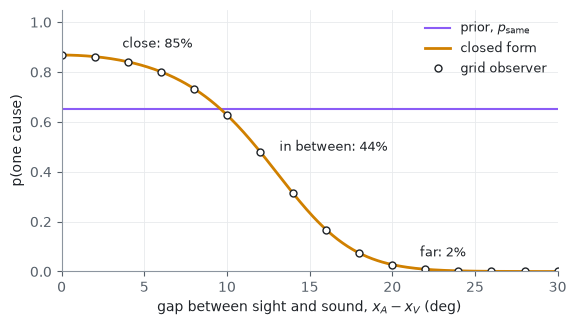

In [5]:
gap = np.linspace(0, 30, 301)
on_grid = (X >= 0) & (X <= 30) & (X % 2 == 0)
i_zero = np.argmin(np.abs(X))

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.axhline(FILM["p_common"], color=PRIOR, lw=1.5, label="prior, $p_\\mathrm{same}$")
ax.plot(gap, p_common_closed_form(0.0, gap, **FILM), color=MODEL, label="closed form")
ax.plot(X[on_grid], p_C1_grid[i_zero, on_grid], "o", ms=5, mfc="white", mec=INK, mew=1, label="grid observer")
for u, name in ((3, "close"), (12.5, "in between"), (21, "far")):  # the film's three sound positions
    p = p_common_closed_form(0.0, u, **FILM)
    ax.annotate(f"{name}: {p:.0%}", (u, p), xytext=(8, 8), textcoords="offset points", fontsize=9)
ax.set(xlabel="gap between sight and sound, $x_A - x_V$ (deg)", ylabel="p(one cause)", ylim=(0, 1.05), xlim=(0, 30))
ax.legend(loc="upper right")
plt.show()

## 3 · A simulated participant

The stimuli follow the paper's design. Flashes fall anywhere in $[-20°, 20°]$, and beeps come from seven speakers at $0°$, $\pm5°$, $\pm10°$ and $\pm15°$. On same/different trials the flash is at the beep's location half of the time, and otherwise anywhere in its range. The simulated participant does 500 UV, 500 UA and 500 BC trials (a participant in the paper did 500, 500 and 1,000, plus 1,000 bisensory localization trials).

The ground truth is the Exp model, with illustrative values chosen so that the noise functions fall within the range of the paper's estimates (its Fig 4). Vision noise rises from 1.0° straight ahead to about 2.5° in the periphery, and hearing noise from 2.0° to about 4.5°; with $k_2 = 0.4$/deg, most of the rise happens within 4° of straight ahead. The noise functions estimated in the paper dip more steeply around 0°; a gentler rise makes the dip easier to see in binned data. The single visual reliability level stands for the paper's high-reliability flashes. The prior width ($\sigma_s = 12°$), $p_\text{same} = 0.5$ and a 1% lapse rate are also illustrative.

The simulator below draws each measurement and computes the observer's posterior for it directly on the $s$ grid, without the tabulated maps that the likelihood uses.

In [6]:
def simulate(theta, model, stim, rng):
    # Responses of the observer to the stimuli in `stim`
    noise_V, noise_A, sigma_s, p_same, lapse = unpack(theta, model)
    prior = normpdf(S, 0, sigma_s) * DS

    def measure(s, noise):
        # draw x ~ N(s, sigma(s)^2); return the likelihood p(x | s') over the s grid, one row per trial
        x = s + noise_sd(s, *noise) * rng.standard_normal(s.size)
        return normpdf(x[:, None], S, noise_sd(S, *noise))

    data = {}
    for task, noise in (("UV", noise_V), ("UA", noise_A)):
        s = stim[task]
        L = measure(s, noise)
        r = L @ (prior * S) / (L @ prior) + SIGMA_MOTOR * rng.standard_normal(s.size)
        lapses = rng.random(s.size) < lapse
        r[lapses] = rng.uniform(-45, 45, lapses.sum())
        data[task] = {"s": s, "r": r}
    s_V, s_A = stim["BC"]
    L_V, L_A = measure(s_V, noise_V), measure(s_A, noise_A)
    like_same = (L_V * L_A) @ prior
    like_diff = (L_V @ prior) * (L_A @ prior)
    p_C1 = p_same * like_same / (p_same * like_same + (1 - p_same) * like_diff)
    same = rng.random(s_V.size) < p_C1  # probability matching
    lapses = rng.random(s_V.size) < lapse
    same[lapses] = rng.random(lapses.sum()) < 0.5
    data["BC"] = {"s_V": s_V, "s_A": s_A, "same": same}
    return data

In [7]:
SPEAKERS = np.array([-15, -10, -5, 0, 5, 10, 15.0])
N_UV, N_UA, N_BC = 500, 500, 500

rng = np.random.default_rng(2026)
s_A_bc = rng.choice(SPEAKERS, N_BC)
s_V_bc = np.where(rng.random(N_BC) < 0.5, s_A_bc, rng.uniform(-20, 20, N_BC))  # same place half the time
stim = {"UV": rng.uniform(-20, 20, N_UV), "UA": rng.choice(SPEAKERS, N_UA), "BC": (s_V_bc, s_A_bc)}

#                  sigma0_V k1_V sigma0_A k1_A  k2  sigma_s p_same lapse
TRUTH = np.array([1.0,     1.5, 2.0,     2.5,  0.4, 12.0,   0.5,   0.01])
data = simulate(TRUTH, "Exp", stim, rng)

t = time.perf_counter()
for _ in range(20):
    log_likelihood(TRUTH, "Exp", data)
print(f"one log-likelihood evaluation: {(time.perf_counter() - t) / 20 * 1e3:.0f} ms")
print(f"'same' responses: {data['BC']['same'].mean():.0%} of BC trials")

one log-likelihood evaluation: 28 ms
'same' responses: 52% of BC trials


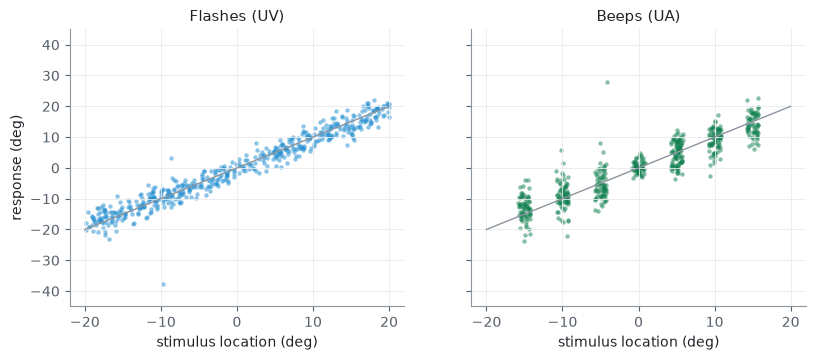

In [8]:
jitter = np.random.default_rng(0).uniform(-0.8, 0.8, N_UA)  # spread the speaker columns for display

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
for ax, (task, colour, title) in zip(axes, (("UV", SIGHT, "Flashes (UV)"), ("UA", SOUND, "Beeps (UA)"))):
    s, r = data[task]["s"], data[task]["r"]
    ax.plot([-20, 20], [-20, 20], color=MUTED, lw=1)
    ax.scatter(s + (jitter if task == "UA" else 0), r, s=10, color=colour, alpha=0.5, lw=0)
    ax.set(title=title, xlabel="stimulus location (deg)", ylim=(-45, 45))
axes[0].set_ylabel("response (deg)")
plt.show()

Responses to flashes near the centre cluster tightly around the diagonal; beeps are noisier, and more so away from the centre. The few responses far from the diagonal are lapses.

## 4 · Maximum-likelihood fits with PyBADS

[BADS](https://acerbilab.github.io/pybads/) (Bayesian Adaptive Direct Search; Acerbi & Ma, 2017) combines a mesh-based direct search with a Gaussian-process surrogate of the target, which proposes where to evaluate next. It is designed for fitting computational models with up to about 20 parameters, whose targets may be rough, noisy, or moderately expensive to evaluate. The paper used it for all its fits with up to 20 free parameters.

BADS takes the function to minimize (here the negative log-likelihood), a starting point, hard bounds, and plausible bounds: a box where the solution probably lies, which sets the scale of the search. Each model is fitted from two random starting points in the plausible box, keeping the better fit.

In [9]:
BOUNDS = {
    #            lb     plb    pub    ub
    "sigma_V":  (0.3,   0.8,   6.0,  15.0),
    "sigma_A":  (0.3,   0.8,   6.0,  15.0),
    "sigma0_V": (0.3,   0.5,   4.0,  10.0),
    "k1_V":     (0.0,   0.2,   4.0,  10.0),
    "sigma0_A": (0.3,   0.5,   4.0,  10.0),
    "k1_A":     (0.0,   0.2,   4.0,  10.0),
    "k2":       (0.02,  0.1,   1.5,   5.0),
    "sigma_s":  (2.0,   4.0,  25.0,  40.0),
    "p_same":   (0.02,  0.2,   0.8,   0.98),
    "lapse":    (1e-4,  0.002, 0.05,  0.2),
}


def bounds(model):
    # -> arrays lb, plb, pub, ub
    return np.array([BOUNDS[name] for name in PARAMS[model]]).T


fits = {}
for model in ("Const", "Exp"):
    lb, plb, pub, ub = bounds(model)
    starts = np.random.default_rng(1)
    for i in range(2):
        x0 = plb + starts.random(lb.size) * (pub - plb)
        bads = BADS(lambda theta: -log_likelihood(theta, model, data), x0, lb, ub, plb, pub,
                    options={"display": "off", "random_seed": i})
        result = bads.optimize()
        print(f"{model:5s} start {i + 1}: -log L = {result.fval:.2f} "
              f"({result.func_count} evaluations, {result.total_time:.0f} s)")
        if model not in fits or result.fval < fits[model].fval:
            fits[model] = result

Const start 1: -log L = 2771.22 (225 evaluations, 14 s)


Const start 2: -log L = 2771.22 (233 evaluations, 15 s)


Exp   start 1: -log L = 2732.88 (449 evaluations, 29 s)


Exp   start 2: -log L = 2732.88 (376 evaluations, 25 s)


In [10]:
def param_table(columns):
    # columns: {heading: (model, theta)}; one row per parameter name
    names = list(dict.fromkeys(n for model, _ in columns.values() for n in PARAMS[model]))
    print(f"{'':10s}" + "".join(f"{h:>10s}" for h in columns))
    for n in names:
        row = [dict(zip(PARAMS[m], th)).get(n) for m, th in columns.values()]
        print(f"{n:10s}" + "".join(f"{v:10.3f}" if v is not None else f"{'-':>10s}" for v in row))


param_table({"truth": ("Exp", TRUTH), "Const": ("Const", fits["Const"].x), "Exp": ("Exp", fits["Exp"].x)})

n_trials = N_UV + N_UA + N_BC
bic = {m: 2 * fits[m].fval + len(PARAMS[m]) * np.log(n_trials) for m in fits}
print(f"\n-log L:  Const {fits['Const'].fval:.1f},  Exp {fits['Exp'].fval:.1f}")
print(f"BIC:     Const {bic['Const']:.1f},  Exp {bic['Exp']:.1f}   (lower is better)")

               truth     Const       Exp
sigma0_V       1.000         -     1.226
k1_V           1.500         -     1.335
sigma0_A       2.000         -     1.769
k1_A           2.500         -     3.216
k2             0.400         -     0.257
sigma_s       12.000    12.650    11.700
p_same         0.500     0.568     0.571
lapse          0.010     0.006     0.005
sigma_V            -     2.306         -
sigma_A            -     4.028         -

-log L:  Const 2771.2,  Exp 2732.9
BIC:     Const 5579.0,  Exp 5524.3   (lower is better)


Exp recovers the shape of the generating noise functions. Const has one noise level per sense and settles between the central and the peripheral noise.

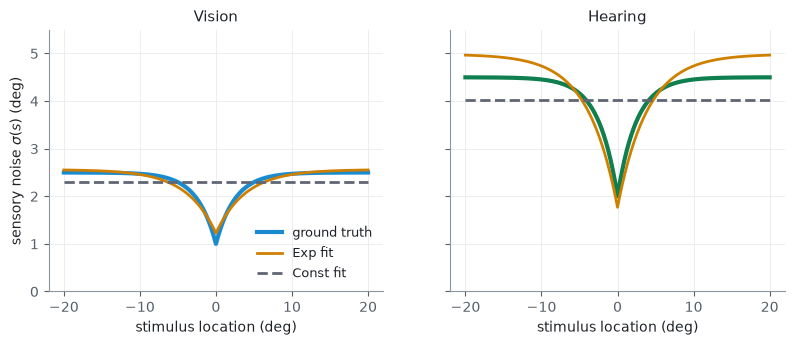

In [11]:
s_plot = np.linspace(-20, 20, 401)
truth_V, truth_A = unpack(TRUTH, "Exp")[:2]
const_V, const_A = unpack(fits["Const"].x, "Const")[:2]
exp_V, exp_A = unpack(fits["Exp"].x, "Exp")[:2]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
panels = ((SIGHT, "Vision", truth_V, exp_V, const_V), (SOUND, "Hearing", truth_A, exp_A, const_A))
for ax, (colour, title, truth, exp_fit, const_fit) in zip(axes, panels):
    ax.plot(s_plot, noise_sd(s_plot, *truth), color=colour, lw=3, label="ground truth")
    ax.plot(s_plot, noise_sd(s_plot, *exp_fit), color=MODEL, label="Exp fit")
    ax.plot(s_plot, noise_sd(s_plot, *const_fit), color=CONST, ls="--", label="Const fit")
    ax.set(title=title, xlabel="stimulus location (deg)", ylim=(0, 5.5))
axes[0].set_ylabel("sensory noise $\\sigma(s)$ (deg)")
axes[0].legend(loc="lower right")
plt.show()

**The diagnostic from the paper and the film.** How spread out are localization responses, as a function of stimulus location? In the paper's data (its Fig 2C, and the inset in the film) the spread dips straight ahead, and a model with constant noise cannot follow. Two details differ from the paper's figure, which shows the SD of responses averaged over 15 participants. The flashes are binned (7 bins, as in the paper), so the SD is computed for the localization error, response minus stimulus, which removes the spread of flash locations within a bin. And errors larger than 15° are left out: lapses are uniform over ±45°, so most of them produce such errors, while the observer's own errors almost never do, and a single lapse would otherwise dominate the SD of a bin of about 70 trials. The bands show what each fitted model predicts for the same statistic: the 5–95% range over 100 simulated repetitions of the experiment. The third panel shows the proportion of "same" responses against the gap between flash and beep: the balance again, now in data.

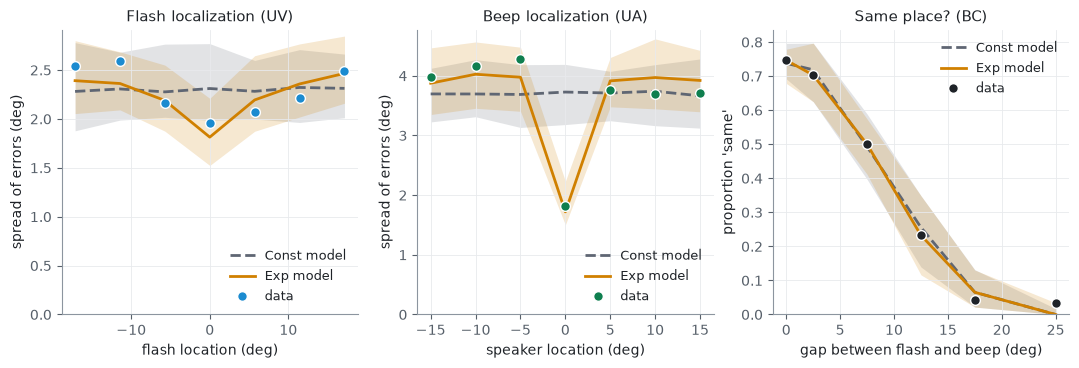

In [12]:
UV_EDGES = np.linspace(-20, 20, 8)  # 7 bins, as in the paper's figures
UV_CENTRES = (UV_EDGES[:-1] + UV_EDGES[1:]) / 2
GAP_EDGES = [1e-9, 5, 10, 15, 20]    # |s_A - s_V|: exactly 0, then 5-deg bins, then above 20
GAP_CENTRES = np.array([0, 2.5, 7.5, 12.5, 17.5, 25])


def spread(errors):
    # SD of localization errors, leaving out errors beyond 15 deg (mostly lapses)
    errors = errors[np.abs(errors) < 15]
    return errors.std(ddof=1)


def summarize(d):
    # spread of localization errors by location (UV, UA) and proportion "same" by gap (BC)
    uv_bin = np.digitize(d["UV"]["s"], UV_EDGES[1:-1])
    error_V = d["UV"]["r"] - d["UV"]["s"]
    error_A = d["UA"]["r"] - d["UA"]["s"]
    spread_V = [spread(error_V[uv_bin == i]) for i in range(7)]
    spread_A = [spread(error_A[d["UA"]["s"] == s]) for s in SPEAKERS]
    gap_bin = np.digitize(np.abs(d["BC"]["s_A"] - d["BC"]["s_V"]), GAP_EDGES)
    p_same = [d["BC"]["same"][gap_bin == i].mean() for i in range(len(GAP_EDGES) + 1)]
    return np.array(spread_V), np.array(spread_A), np.array(p_same)


def predictive(theta, model, n_rep=100, seed=0):
    # the same statistics on n_rep simulated repetitions of the experiment
    rep_rng = np.random.default_rng(seed)
    reps = [summarize(simulate(theta, model, stim, rep_rng)) for _ in range(n_rep)]
    return [np.stack(stat) for stat in zip(*reps)]


observed = summarize(data)
predicted = {m: predictive(fits[m].x, m) for m in ("Const", "Exp")}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))
panels = (
    (UV_CENTRES, SIGHT, "Flash localization (UV)", "flash location (deg)", "spread of errors (deg)"),
    (SPEAKERS, SOUND, "Beep localization (UA)", "speaker location (deg)", "spread of errors (deg)"),
    (GAP_CENTRES, INK, "Same place? (BC)", "gap between flash and beep (deg)", "proportion 'same'"),
)
for k, (ax, (x, colour, title, xlabel, ylabel)) in enumerate(zip(axes, panels)):
    for m, line_colour, ls in (("Const", CONST, "--"), ("Exp", MODEL, "-")):
        lo, mid, hi = np.percentile(predicted[m][k], [5, 50, 95], axis=0)
        ax.fill_between(x, lo, hi, color=line_colour, alpha=0.18, lw=0)
        ax.plot(x, mid, color=line_colour, ls=ls, label=f"{m} model")
    ax.plot(x, observed[k], "o", color=colour, mec="white", mew=1, ms=7, zorder=3, label="data")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel, ylim=(0, None))
    ax.legend(loc="lower right" if k < 2 else "upper right")
plt.show()

Straight ahead, both senses are more precise than in the periphery, most clearly hearing. Exp follows the dip; Const predicts the same spread everywhere. The two models predict the same/different judgments almost equally well, so in this miniature most of the evidence for Exp comes from localization, above all of beeps.

## 5 · Posteriors and model evidence with PyVBMC

A maximum-likelihood fit gives one parameter vector. [VBMC](https://acerbilab.github.io/pyvbmc/) (Variational Bayesian Monte Carlo; Acerbi, 2018, 2020) returns an approximate posterior over the parameters and a lower bound on the log model evidence, the ELBO, from a small budget of likelihood evaluations (here, fewer than 200 per model). It fits a Gaussian-process surrogate to the log posterior, approximates the posterior with a mixture of Gaussians, and chooses where to evaluate next by active sampling.

VBMC takes the log-likelihood, a prior, bounds, plausible bounds and a starting point, here the BADS solution. The prior is flat on the plausible box and falls smoothly to zero at the hard bounds (`SplineTrapezoidal`). The evidence depends on the prior: a wider prior on the extra parameters of Exp would lower its evidence (the Occam factor).

In [13]:
posteriors = {}
for model in ("Const", "Exp"):
    lb, plb, pub, ub = bounds(model)
    np.random.seed(2026)  # PyVBMC draws from NumPy's global random state
    vbmc = VBMC(
        lambda theta: log_likelihood(theta, model, data),
        fits[model].x[None, :],  # PyVBMC takes row vectors
        lb[None, :], ub[None, :], plb[None, :], pub[None, :],
        prior=SplineTrapezoidal(lb, plb, pub, ub),
        options={"display": "off"},
    )
    vp, results = vbmc.optimize()
    posteriors[model] = vp, results
    print(f"{model:5s}: ELBO = {results['elbo']:.2f} ± {results['elbo_sd']:.2f} "
          f"({results['func_count']} evaluations, convergence: {results['convergence_status']})\n")

Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -2785.969 +/-0.008.


Const: ELBO = -2785.97 ± 0.01 (95 evaluations, convergence: probable)



Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -2754.663 +/-0.038.


Exp  : ELBO = -2754.66 ± 0.04 (155 evaluations, convergence: probable)



The posterior of the Exp model, with the generating values and the BADS fit:

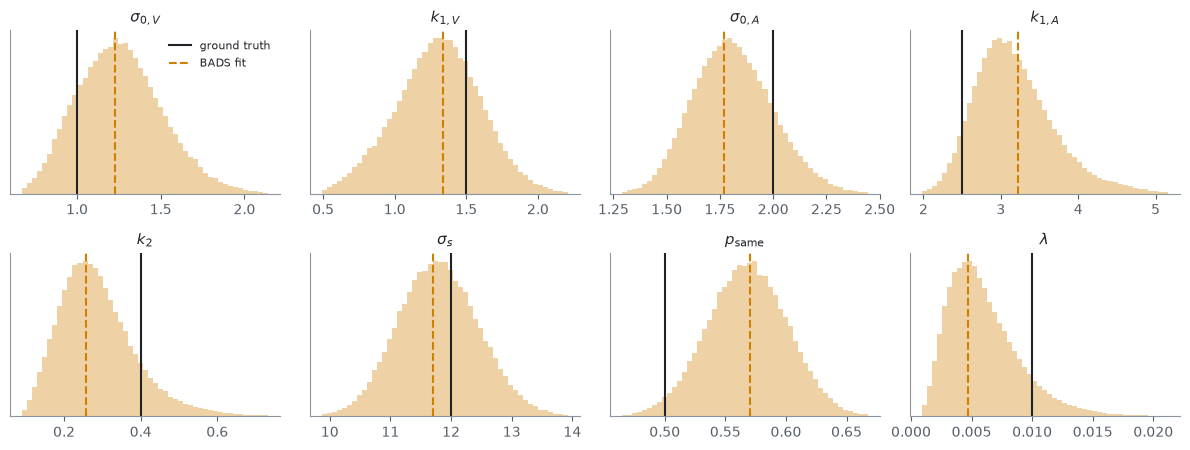

             truth   median   90% credible interval
sigma0_V     1.000    1.246   [0.871, 1.703]
k1_V         1.500    1.312   [0.802, 1.787]
sigma0_A     2.000    1.805   [1.519, 2.139]
k1_A         2.500    3.116   [2.454, 4.144]
k2           0.400    0.274   [0.151, 0.475]
sigma_s     12.000   11.786   [10.742, 12.909]
p_same       0.500    0.568   [0.513, 0.622]
lapse        0.010    0.005   [0.002, 0.012]


In [14]:
LABELS = {
    "sigma0_V": r"$\sigma_{0,V}$", "k1_V": r"$k_{1,V}$", "sigma0_A": r"$\sigma_{0,A}$", "k1_A": r"$k_{1,A}$",
    "k2": r"$k_2$", "sigma_s": r"$\sigma_s$", "p_same": r"$p_\mathrm{same}$", "lapse": r"$\lambda$",
}
vp, _ = posteriors["Exp"]
samples, _ = vp.sample(100_000)

fig, axes = plt.subplots(2, 4, figsize=(12, 4.6))
for i, (ax, name) in enumerate(zip(axes.flat, PARAMS["Exp"])):
    lo, hi = np.percentile(samples[:, i], [0.1, 99.9])
    ax.hist(samples[:, i], bins=np.linspace(lo, hi, 50), density=True, color=MODEL, alpha=0.35, lw=0)
    ax.axvline(TRUTH[i], color=INK, lw=1.5, label="ground truth")
    ax.axvline(fits["Exp"].x[i], color=MODEL, lw=1.5, ls="--", label="BADS fit")
    ax.set(title=LABELS[name], yticks=[])
    ax.grid(False)
axes[0, 0].legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

q05, q50, q95 = np.percentile(samples, [5, 50, 95], axis=0)
print(f"{'':10s}{'truth':>8s}{'median':>9s}   90% credible interval")
for name, t, m, a, b in zip(PARAMS["Exp"], TRUTH, q50, q05, q95):
    print(f"{name:10s}{t:8.3f}{m:9.3f}   [{a:.3f}, {b:.3f}]")

Most generating values lie well inside their posteriors. With eight parameters and 90% intervals, about one is expected to fall outside its interval by chance; here $p_\text{same}$ narrowly does. Relative to its value, the sharpness of the dip, $k_2$, is the least tightly constrained noise parameter.

**Model comparison.** The difference between the two ELBOs approximates the log Bayes factor, provided each bound is close to its evidence, as it typically is for smooth, unimodal posteriors like these. Its uncertainty combines the two ELBO uncertainties. The paper compared models with AIC and BIC; for reference, −ΔBIC/2 from the BADS fits is a rough approximation of the same quantity.

In [15]:
(_, res_const), (_, res_exp) = posteriors["Const"], posteriors["Exp"]
d_elbo = res_exp["elbo"] - res_const["elbo"]
d_elbo_sd = np.hypot(res_exp["elbo_sd"], res_const["elbo_sd"])
print(f"log evidence, Exp - Const:  {d_elbo:.1f} ± {d_elbo_sd:.2f}  (ΔELBO)")
print(f"-ΔBIC / 2, Exp - Const:     {(bic['Const'] - bic['Exp']) / 2:.1f}")

log evidence, Exp - Const:  31.3 ± 0.04  (ΔELBO)
-ΔBIC / 2, Exp - Const:     27.4


The evidence favours Exp by a wide margin, far beyond the uncertainty of the estimate, and agrees with the BIC approximation in direction and rough size.

## 6 · What this showed, and where to go next

- A causal-inference observer with eccentricity-dependent noise needs numerical integration, but tabulating what the observer computes from its measurements keeps a full log-likelihood evaluation to milliseconds.
- On data from a simulated participant whose noise is lowest straight ahead, a constant-noise model misses the dip in response spread at the centre, and the Exp model recovers the shape of the noise functions.
- PyBADS found the maximum-likelihood fits. PyVBMC returned the parameter posteriors and each model's log evidence, with its uncertainty.

This is a miniature on simulated data, not a reproduction of the paper's analysis. The paper fitted 15 participants on five tasks, with three visual reliability levels, auditory range recalibration and extra noise on bisensory trials. It inferred the shapes of noise and prior with semiparametric models, distilled them into parametric families, and compared three causal-inference strategies. It used BADS for all its fits with up to 20 free parameters and CMA-ES for the 40-parameter semiparametric fits, and compared models with AIC and BIC.

**Try next**
- Replace the Gaussian prior with the paper's Gaussian–Laplace mixture (eq. 10). The prior is one line in `observer_maps` and one in `simulate`; its two extra parameters ($b$ and $\omega$) go into `PARAMS`, `BOUNDS` and `unpack`. Then compare the two priors on data simulated from each.
- Swap probability matching for model selection or model averaging in the same/different task, or add the bisensory localization tasks (eqs. 4–7 and 16–18).

**Tools**
- PyBADS, for maximum-likelihood and MAP fits: <https://acerbilab.github.io/pybads/>
- PyVBMC, for posteriors and model evidence: <https://acerbilab.github.io/pyvbmc/>
- PyIBS, for models you can simulate but whose likelihood you cannot compute: inverse binomial sampling gives unbiased estimates of the log-likelihood from simulations, for use with the noisy-target modes of BADS and VBMC: <https://github.com/acerbilab/pyibs>
- The paper's analysis code: <https://github.com/LSZ2001/Audiovisual-causal-inference>

**References**
- Acerbi L (2018). Variational Bayesian Monte Carlo. *Advances in Neural Information Processing Systems* 31.
- Acerbi L (2020). Variational Bayesian Monte Carlo with noisy likelihoods. *Advances in Neural Information Processing Systems* 33.
- Acerbi L & Ma WJ (2017). Practical Bayesian optimization for model fitting with Bayesian Adaptive Direct Search. *Advances in Neural Information Processing Systems* 30.
- Huggins B, Li C, Tobaben M, Aarnos M & Acerbi L (2023). PyVBMC: Efficient Bayesian inference in Python. *Journal of Open Source Software* 8(86): 5428.
- Körding KP, Beierholm U, Ma WJ, Quartz S, Tenenbaum JB & Shams L (2007). Causal inference in multisensory perception. *PLoS ONE* 2(9): e943.
- Liu S, Holland T, Ma WJ & Acerbi L (2026). Distilling noise characteristics and prior expectations in multisensory causal inference. *PLOS Computational Biology* 22(5): e1014251.
- Singh SG & Acerbi L (2024). PyBADS: Fast and robust black-box optimization in Python. *Journal of Open Source Software* 9(94): 5694.